# Subset selection, ridge and lasso

The previous notebooks chose predictors with tests and information criteria. This notebook takes the predictive point of view: **which model makes the smallest error on new data?** We compare four approaches on the same problem:

- **ordinary least squares** with all predictors;
- **best subset selection**: fit every possible combination of predictors and keep the best by BIC;
- **ridge regression**: least squares plus a penalty $\lambda \sum_j \beta_j^2$ that shrinks all coefficients towards zero;
- **lasso**: least squares plus a penalty $\lambda \sum_j |\beta_j|$ that shrinks coefficients and sets some of them exactly to zero, performing variable selection.

The penalty strength $\lambda$ is chosen by cross-validation. All models are fitted on a training set and evaluated on a held-out test set.

**Data:** 777 US colleges, with 17 characteristics each. The goal is to predict the number of applications received (`Apps`).

In [1]:
import itertools
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LassoCV, LinearRegression, RidgeCV, lasso_path
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams["figure.dpi"] = 100

In [2]:
college = pd.read_csv("data/college.csv", index_col=0)
college["Private"] = (college["Private"] == "Yes").astype(int)
X, y = college.drop(columns="Apps"), college["Apps"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)
print(f"training set: {len(X_train)} colleges, test set: {len(X_test)} colleges, {X.shape[1]} predictors")
X.columns.tolist()

training set: 582 colleges, test set: 195 colleges, 17 predictors


['Private',
 'Accept',
 'Enroll',
 'Top10perc',
 'Top25perc',
 'F.Undergrad',
 'P.Undergrad',
 'Outstate',
 'Room.Board',
 'Books',
 'Personal',
 'PhD',
 'Terminal',
 'S.F.Ratio',
 'perc.alumni',
 'Expend',
 'Grad.Rate']

The predictors describe admissions (`Accept`, `Enroll`, share of students from the top 10%/25% of their high school class), size (`F.Undergrad`, `P.Undergrad`), costs (`Outstate` tuition, `Room.Board`, `Books`, `Personal`), faculty (`PhD`, `Terminal`, `S.F.Ratio`), alumni donations, expenditure per student, graduation rate, and whether the college is private.

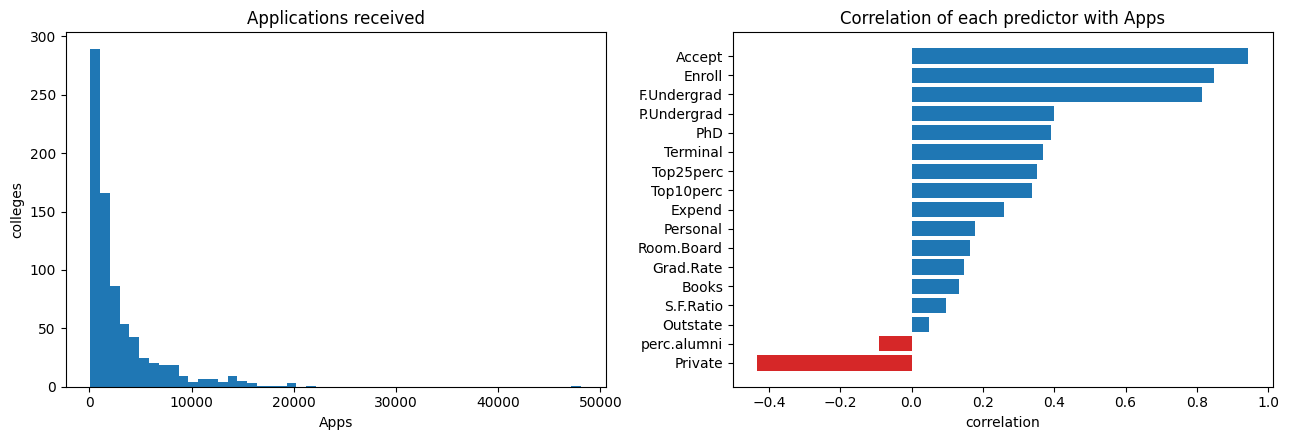

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(y, bins=50, color="tab:blue")
axes[0].set(title="Applications received", xlabel="Apps", ylabel="colleges")
corr = X.corrwith(y).sort_values()
axes[1].barh(corr.index, corr.values, color=np.where(corr > 0, "tab:blue", "tab:red"))
axes[1].set(title="Correlation of each predictor with Apps", xlabel="correlation")
fig.tight_layout()
plt.show()

Applications are very skewed (a few large universities receive tens of thousands), and they are almost perfectly correlated with the number of accepted applicants (`Accept`, r ≈ 0.94). The size variables follow.

As a reference, predicting every college with the training mean gives the error any useful model has to beat. We measure errors as root mean squared error (RMSE), in number of applications.

In [4]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

results = {"mean only (baseline)": rmse(y_test, np.full(len(y_test), y_train.mean()))}

ols = make_pipeline(StandardScaler(), LinearRegression()).fit(X_train, y_train)
results["least squares, all 17 predictors"] = rmse(y_test, ols.predict(X_test))
pd.Series(results, name="test RMSE").round(0)

mean only (baseline)                3587.0
least squares, all 17 predictors     798.0
Name: test RMSE, dtype: float64

## 1. Best subset selection

With 17 predictors there are $2^{17} - 1 = 131{,}071$ possible models. For each size $k$ we find the combination with the smallest residual sum of squares, then compare sizes with BIC, which penalises every extra parameter by $\log n$. Solving the least squares problems directly with NumPy keeps the search to a few seconds.

131,071 models fitted in 8.0 s


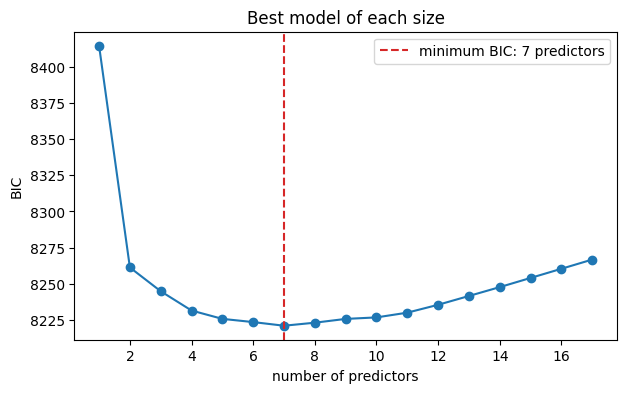

Selected predictors: ['Accept', 'Enroll', 'Top10perc', 'Top25perc', 'Outstate', 'Room.Board', 'Expend']


In [5]:
def best_subset(X, y):
    """For each model size k, the predictors with the lowest RSS (an intercept is always included)."""
    Z = np.column_stack([np.ones(len(X)), X.to_numpy(dtype=float)])
    target = y.to_numpy(dtype=float)
    n, columns = len(X), list(X.columns)
    best = {}
    for k in range(1, len(columns) + 1):
        best_rss, best_combo = np.inf, None
        for combo in itertools.combinations(range(len(columns)), k):
            A = Z[:, (0,) + tuple(i + 1 for i in combo)]
            beta = np.linalg.lstsq(A, target, rcond=None)[0]
            rss = np.sum((target - A @ beta) ** 2)
            if rss < best_rss:
                best_rss, best_combo = rss, combo
        best[k] = {
            "predictors": [columns[i] for i in best_combo],
            "RSS": best_rss,
            "BIC": n * np.log(best_rss / n) + (k + 1) * np.log(n),
        }
    return pd.DataFrame(best).T

start = time.time()
subsets = best_subset(X_train, y_train)
print(f"{2 ** X.shape[1] - 1:,} models fitted in {time.time() - start:.1f} s")

best_k = subsets["BIC"].astype(float).idxmin()
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(subsets.index, subsets["BIC"], "o-")
ax.axvline(best_k, color="tab:red", ls="--", label=f"minimum BIC: {best_k} predictors")
ax.set(xlabel="number of predictors", ylabel="BIC", title="Best model of each size")
ax.legend()
plt.show()
print("Selected predictors:", subsets.loc[best_k, "predictors"])

In [6]:
subset_cols = subsets.loc[best_k, "predictors"]
subset_model = LinearRegression().fit(X_train[subset_cols], y_train)
results[f"best subset ({best_k} predictors)"] = rmse(y_test, subset_model.predict(X_test[subset_cols]))
pd.Series(results, name="test RMSE").round(0)

mean only (baseline)                3587.0
least squares, all 17 predictors     798.0
best subset (7 predictors)           849.0
Name: test RMSE, dtype: float64

## 2. Ridge and lasso

Both penalties act on the size of the coefficients, so the predictors must first be put on a common scale: otherwise a variable measured in dollars and one measured in percent would be penalised very differently. A `StandardScaler` in the pipeline takes care of this, and it is fitted on the training folds only.

The penalty strength is chosen by 10-fold cross-validation over a grid of values.

In [7]:
ridge = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 4, 200), cv=10)).fit(X_train, y_train)
lasso = make_pipeline(StandardScaler(), LassoCV(cv=10, random_state=0, max_iter=50_000)).fit(X_train, y_train)

print(f"ridge: lambda = {ridge[-1].alpha_:.2f}")
print(f"lasso: lambda = {lasso[-1].alpha_:.2f}, non-zero coefficients: {(lasso[-1].coef_ != 0).sum()} of {X.shape[1]}")
results["ridge"] = rmse(y_test, ridge.predict(X_test))
results["lasso"] = rmse(y_test, lasso.predict(X_test))

ridge: lambda = 11.10
lasso: lambda = 22.80, non-zero coefficients: 13 of 17


The **lasso path** shows how the coefficients change as the penalty grows: with a large $\lambda$ every coefficient is zero, and as $\lambda$ decreases the predictors enter the model one by one, the most useful first. The dashed line marks the value chosen by cross-validation.

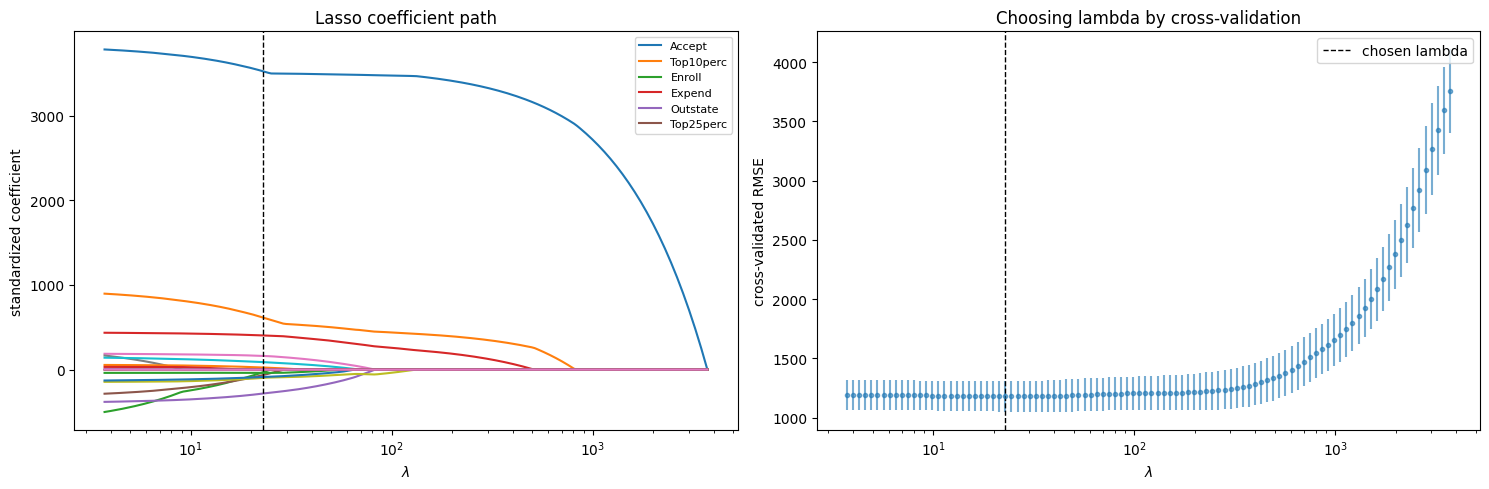

In [8]:
X_train_std = StandardScaler().fit_transform(X_train)
alphas, coefs, _ = lasso_path(X_train_std, y_train, n_alphas=200)
order = np.argsort(-np.abs(coefs[:, -1]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
for i in order:
    ax1.plot(alphas, coefs[i], label=X.columns[i] if i in order[:6] else None)
ax1.axvline(lasso[-1].alpha_, color="black", ls="--", lw=1)
ax1.set(xscale="log", xlabel=r"$\lambda$", ylabel="standardized coefficient", title="Lasso coefficient path")
ax1.legend(fontsize=8)

fold_rmse = np.sqrt(lasso[-1].mse_path_)  # one column per cross-validation fold
ax2.errorbar(lasso[-1].alphas_, fold_rmse.mean(axis=1), yerr=fold_rmse.std(axis=1) / np.sqrt(fold_rmse.shape[1]),
             fmt="o", ms=3, alpha=0.6)
ax2.axvline(lasso[-1].alpha_, color="black", ls="--", lw=1, label="chosen lambda")
ax2.set(xscale="log", xlabel=r"$\lambda$", ylabel="cross-validated RMSE", title="Choosing lambda by cross-validation")
ax2.legend()
fig.tight_layout()
plt.show()

In [9]:
coef_table = pd.DataFrame({
    "least squares": ols[-1].coef_,
    "ridge": ridge[-1].coef_,
    "lasso": lasso[-1].coef_,
}, index=X.columns).round(1)
coef_table.sort_values("least squares", key=abs, ascending=False)

,least squares,ridge,lasso
Accept,3837.4,3392.7,3527.2
Top10perc,955.9,761.8,617.5
Enroll,-670.8,-139.5,-32.5
Expend,441.2,445.9,403.0
Outstate,-401.0,-320.5,-283.7
Top25perc,-332.4,-194.8,-66.4
F.Undergrad,282.4,169.4,-0.0
Room.Board,192.5,211.1,161.2
Grad.Rate,151.7,162.4,88.3
Private,-149.8,-149.6,-99.0


The coefficients are on the standardized scale, so their sizes are comparable: they are the change in applications for a one standard deviation change in the predictor. `Accept` dominates every model. Ridge shrinks all coefficients a little, while the lasso sets the least useful ones exactly to zero and keeps a smaller model.

## 3. Comparison on the test set

In [10]:
summary = pd.Series(results, name="test RMSE").round(0).sort_values()
summary

least squares, all 17 predictors     798.0
ridge                                826.0
lasso                                846.0
best subset (7 predictors)           849.0
mean only (baseline)                3587.0
Name: test RMSE, dtype: float64

All four models cut the baseline error by more than 75%, and their test errors are close to each other. Plain least squares is even marginally the best. This is not a failure of regularization: with 582 training colleges and only 17 predictors, least squares already estimates the coefficients precisely, so there is little variance for the penalty to remove. The differences of a few dozen applications are also within the noise of a single train/test split.

## 4. When does regularization pay off?

Shrinkage trades a little bias for a reduction in variance. That trade is worth it when the coefficients are estimated from few observations relative to the number of predictors. To see this, we repeat the comparison many times, each time training on a small random sample of colleges and testing on the same held-out test set.

In [11]:
rng = np.random.default_rng(0)
models = {
    "least squares": lambda: make_pipeline(StandardScaler(), LinearRegression()),
    "ridge": lambda: make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 4, 60), cv=5)),
    "lasso": lambda: make_pipeline(StandardScaler(), LassoCV(cv=5, n_alphas=60, max_iter=20_000)),
}
records = []
for size in [25, 40, 80, 200, len(X_train)]:
    for rep in range(30 if size < len(X_train) else 1):
        idx = rng.choice(len(X_train), size, replace=False)
        X_s, y_s = X_train.iloc[idx], y_train.iloc[idx]
        for name, make in models.items():
            fitted = make().fit(X_s, y_s)
            records.append({"training size": size, "model": name, "test RMSE": rmse(y_test, fitted.predict(X_test))})

learning = pd.DataFrame(records).groupby(["training size", "model"])["test RMSE"].median().unstack()
learning.round(0)

model,lasso,least squares,ridge
training size,,,
25,1253.0,1773.0,1460.0
40,1143.0,1603.0,1414.0
80,978.0,1074.0,1096.0
200,888.0,910.0,946.0
582,816.0,798.0,801.0


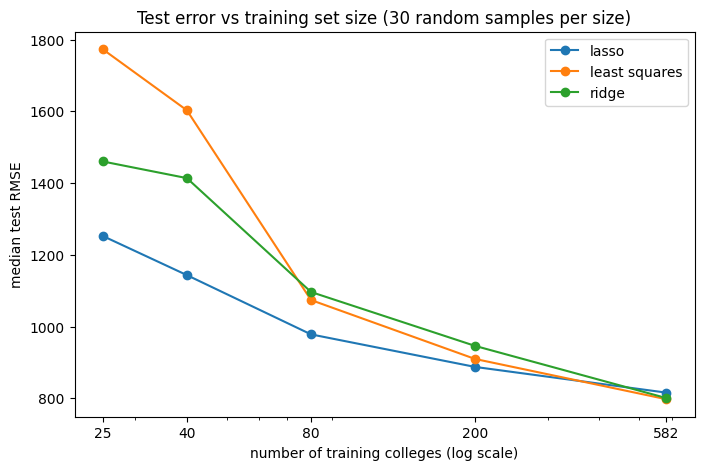

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
for name in learning.columns:
    ax.plot(learning.index, learning[name], "o-", label=name)
ax.set(xscale="log", xlabel="number of training colleges (log scale)", ylabel="median test RMSE",
       title="Test error vs training set size (30 random samples per size)")
ax.set_xticks(learning.index, labels=learning.index)
ax.legend()
plt.show()

With few training colleges, least squares overfits badly: with 25 colleges it estimates 18 parameters from 25 points. The lasso, which can drop irrelevant predictors entirely, does best, and ridge sits in between. As the training set grows, the advantage disappears and all methods converge to the same error.

**Takeaway:** regularization is not automatically better. It helps when the data are scarce relative to the number of predictors, and it costs little when they are not.

## 5. What drives the predictions?

Coefficients describe the model's equation; **permutation importance** describes how much the model actually relies on each predictor. It shuffles one column of the test set at a time and measures how much the error increases. It works for any model, so it can be used to compare very different ones.

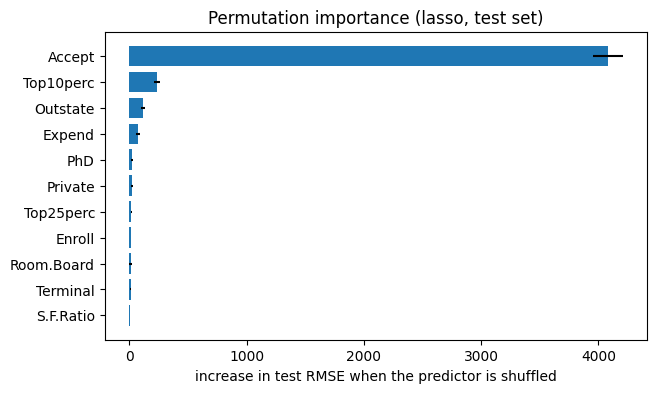

In [13]:
perm = permutation_importance(lasso, X_test, y_test, n_repeats=30, random_state=0, scoring="neg_root_mean_squared_error")
importance = pd.Series(perm.importances_mean, index=X.columns).sort_values()
importance = importance[importance > 1]

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(importance.index, importance.values, xerr=pd.Series(perm.importances_std, index=X.columns)[importance.index], color="tab:blue")
ax.set(xlabel="increase in test RMSE when the predictor is shuffled", title="Permutation importance (lasso, test set)")
plt.show()

The model relies overwhelmingly on `Accept`. Shuffling it increases the test error about five-fold, while every other predictor contributes only marginally.

This raises a practical question. The number of accepted students is only known *after* the applications have been received and processed, so a model built on it is useless for **forecasting** applications in advance. It is still useful to describe the data or to fill in missing values. If the goal is forecasting, we should only use information available beforehand:

In [14]:
forecast_cols = [c for c in X.columns if c not in ("Accept", "Enroll")]
forecast = make_pipeline(StandardScaler(), LassoCV(cv=10, random_state=0, max_iter=50_000)).fit(X_train[forecast_cols], y_train)
print(f"lasso without Accept and Enroll: test RMSE = {rmse(y_test, forecast.predict(X_test[forecast_cols])):.0f}")
pd.Series(forecast[-1].coef_, index=forecast_cols).round(0).loc[lambda s: s != 0].sort_values(key=abs, ascending=False)

lasso without Accept and Enroll: test RMSE = 1514


F.Undergrad    3110.0
Expend          495.0
Grad.Rate       427.0
Room.Board      408.0
Top10perc       367.0
perc.alumni    -167.0
Personal       -115.0
Private        -113.0
P.Undergrad     -87.0
S.F.Ratio        77.0
Terminal        -63.0
Books            48.0
dtype: float64

Without the admission figures the error roughly doubles, but it remains far below the baseline, and the model now says something more useful: the number of applications is driven mainly by the **size** of the college (full-time undergraduates) and by its **quality and reputation** (expenditure per student, graduation rate, share of top students).

## Summary

- Best subset selection, ridge and lasso all address the same problem: too many parameters estimated from too little data.
- Penalised models need **standardized predictors**, and the penalty strength should be chosen by **cross-validation** on the training set only.
- With plenty of data relative to the number of predictors, all methods perform alike. With **scarce data**, the lasso and ridge clearly beat least squares.
- The lasso also gives **sparse**, easier-to-read models.
- Feature importance can reveal predictors that make a model accurate but useless for its real purpose. Always ask whether a predictor will be **available at prediction time**.